# Assignment #2 - Convolutional Neural Networks

<font color="red"> <b> Due: Mar 6 (Friday) 11:00 pm </b> </font>

<font color="blue"> Abeoseh Flemister </font>

# Introduction

[General introduction of this writing assignment] Describe the objective of this assignment. You can briefly state how you accompilsh it.

In [ ]:
from keras.applications.resnet50 import ResNet50
# import torchvision.transforms as transforms
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
print("TF version:", tf.__version__)

import tensorflow_datasets as tfds
import tensorflow as tf

import matplotlib.pyplot as plt
import numpy as np

import keras_tuner

import os
os.environ['SM_FRAMEWORK'] = 'tf.keras'

import segmentation_models as sm 

import tensorflow_addons as tfa

import pandas as pd

TF version: 2.20.0


# Data

**Introduce** your image data and **visualize** them. Describe your observations about the data.
Please check some of visualizations in the labs (you can explore more for others).

**Please do not use the data we practiced in the lab. Also, make sure to play with about 1000 samples. You can scale down or up the image if need.**


In [154]:
# create a new generator
imagegen = keras.preprocessing.image.ImageDataGenerator()


# load train data
train = imagegen.flow_from_directory("./card_archive/train/", class_mode="categorical", shuffle=True, batch_size=128, target_size=(224, 224))
# load val data
val = imagegen.flow_from_directory("./card_archive/valid/", class_mode="categorical", shuffle=True, batch_size=128, target_size=(224, 224))
# load the test data
test = imagegen.flow_from_directory("./card_archive/test/", class_mode="categorical", shuffle=True, batch_size=128, target_size=(224, 224))


classes = pd.read_csv("./card_archive/cards.csv").loc[:,["class index", "labels"]].drop_duplicates(subset=["class index", "labels"])
classes = {classes.iloc[i,0]: classes.iloc[i,1] for i in range(classes.shape[0])}

Found 7624 images belonging to 53 classes.
Found 265 images belonging to 53 classes.
Found 265 images belonging to 53 classes.


As we can see the cards are highly varied which means the model will not overfit to the image on the inside of the card.

In [ ]:
def show_img(x, title="", bot=""): ## bot is bottom
    plt.imshow(x)
    plt.xticks([])
    plt.yticks([])
    plt.title(title)
    plt.xlabel(bot)
plt.figure(figsize = (10,5))

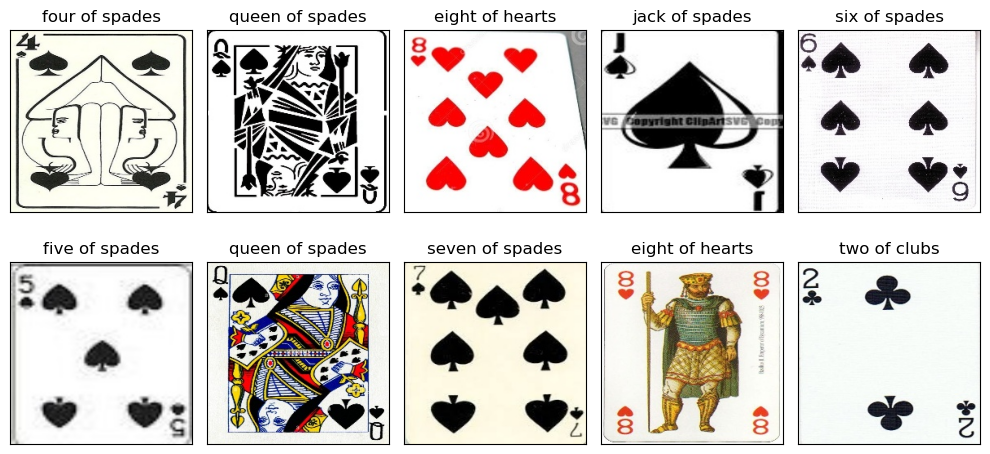

In [156]:
images, labels = next(train)

plt.figure(figsize = (10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    show_img(images[i]/255.0, list(classes.values())[ (labels[i] == 1).nonzero()[0].item() ])

plt.tight_layout()

I am multi-hot encoding the labels since each image contains multiple labels. 

The original image size is 500, 333, 3 but I am resizing it to be 128, 128, 3. Since the images contain multiple classes with some of them (such as bottles) being small, I don't want to make the images too pixelated since it would make it hard to classify the images. 

The test dataset does not have publically available class labels. This makes evaluation of the test sets preformance infeasible so I will use the validation dataset as the validation and test dataset.

## 

# ResNet-50

To save your computation, we leverage pretrained models. Using transfer learning, we only finetune ResNet-50 for image classification and image segmentation.

Summarize the ResNet-50 model here before start loading it, and then implement the codes that load the base model.


<font color="red"> NOTE: We do not consider comments in the code cell as a proper writing. Make sure explain in a Markdown cell not regardless the comment in the code cell. </font>


# Helper Functions

These are the functions that all parts (classification without augmentation, classification with augmentation, and segmentation) will use. 

In [18]:
def plot_learning(history, title, label: str, metric, val_metric):
    """
      title: graph name
      label: y-axis label
      metric: metric you're plotting
      val_metric: validation metric you're plotting
    """
    plt.plot(history.history[metric], label=metric)
    plt.plot(history.history[val_metric], label=val_metric)
    plt.xlabel('Epoch')
    plt.ylabel(f'{label}')
    plt.title(title)
    plt.legend()
    plt.show()

# Image Classification

Here are checklist items that you should work on:

1. Explain your ResNet-50 based CNN for image classification and implement it.
1. Load your image classification data, and then train the image classifier.
1. Properly search hyperparameters to tune the best performing model (report hyperparameter search process, e.g., cross validation).
1. Visualize and evaluate the performance of your image classification.

Place these items under the following Method and Experiment subsections.


## Method

In [158]:
res_base = ResNet50(include_top=False, weights='imagenet', input_shape = (224,224,3))
res_base.trainable = False


In [9]:
class ResPretrained(keras.Model):
    def __init__(self):
        super().__init__()

        # Bias
        bias = tf.Variable(tf.random.normal([3]), trainable=True, name="bias")

        # Single Sequential model
        self.model = keras.Sequential([
            layers.Input(shape=(128,128,3)),
            layers.Lambda(keras.applications.vgg16.preprocess_input),
            layers.Lambda(lambda x: tf.nn.bias_add(x, bias)),
            res_base,
            layers.Flatten(),
            layers.Dense(256),
            layers.Dropout(0.5),
            layers.Dense(20, activation="sigmoid"),
        ])
        self.model.summary()

    # def call(self, inputs):
    #     return self.model(inputs)

ResPretrainedModel = ResPretrained()
ResPretrainedModel.model.compile(loss = "binary_crossentropy", optimizer="rmsprop", metrics=[tf.keras.metrics.BinaryAccuracy(),tf.keras.metrics.Precision(),tf.keras.metrics.Recall()])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,981,716 (122.00 MB)

 Trainable params: 8,394,004 (32.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

On the output layer I am using sigmoid where for each of the 20 classes I am predicting if the image contains that class. 

First I want to do a random search do determine the best hyperparameters for the model. 

I am tuning:
1. the number of units in the hidden dense layer with possible values of 8, 100, 265
2. 

In [168]:
def build_model(hp):
    bias = tf.Variable(tf.random.normal([3]), trainable=True, name="bias")

    model = keras.Sequential([
                layers.Input(shape=(224,224,3)),
                layers.Lambda(keras.applications.vgg16.preprocess_input),
                layers.Lambda(lambda x: tf.nn.bias_add(x, bias)),
                res_base,
                layers.Flatten(),
                layers.Dense(hp.Choice('units', [8, 100, 265])),
                layers.Dropout(hp.Choice('rate', [0.2, 0.5, 0.6])),
                layers.Dense(53, activation="softmax"),
            ])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

              
    model.compile(optimizer=keras.optimizers.Adam(learning_rate = hp_learning_rate),
                  loss = "categorical_crossentropy", 
                  metrics = ["accuracy"])
    return model

## Experiments

In [ ]:
tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5)

tuner.search(train, epochs=10, validation_data=val)

classify_noaugment = tuner.get_best_models()[0]

Trial 1 Complete [00h 42m 16s]
val_loss: 9.276032447814941

Best val_loss So Far: 9.276032447814941
Total elapsed time: 00h 42m 16s

Search: Running Trial #2

Value             |Best Value So Far |Hyperparameter
265               |100               |units
0.6               |0.5               |rate
0.01              |0.001             |learning_rate

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 279s 4s/step - accuracy: 0.3238 - loss: 569.9339 - val_accuracy: 0.5509 - val_loss: 220.7833
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 244s 4s/step - accuracy: 0.5940 - loss: 253.2157 - val_accuracy: 0.6528 - val_loss: 190.8901
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.6626 - loss: 242.0487 - val_accuracy: 0.6755 - val_loss: 243.8994
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 250s 4s/step - accuracy: 0.7247 - loss: 228.5856 - val_accuracy: 0.7094 - val_loss: 268.7681
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.7550 - loss: 250.5398 - val_accuracy: 0.7585 - val_loss: 18

Now I can see the best values from the random search. These are the values I will use when training the model. 

In [ ]:

print(f"Best number of units: {tuner.get_best_hyperparameters()[0].get('units')}")
print(f"Best dropout rate: {tuner.get_best_hyperparameters()[0].get('rate')}")
print(f"Best learning rate: {tuner.get_best_hyperparameters()[0].get('learning_rate')}")

classify_noaugment.summary()


Best number of units: 100
Best dropout rate: 0.2
Best learning rate: 0.0001


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     3,276,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,145,554 (115.00 MB)

 Trainable params: 3,278,920 (12.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 3,278,922 (12.51 MB)

I am going to use the best model and train for 20 epochs with 57 steps per an epoch. 
|Best |value |
|---------------------| ----|
|units | 100 |
|dropout rate | 0.2 |
|learning rate | 0.0001 |

In [ ]:
Resnoaugment_History = classify_noaugment.fit(train, epochs = 20,
                verbose = 1, validation_data=val)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - binary_accuracy: 0.9253 - loss: 0.2172 - precision: 0.5957 - recall: 0.1407 - val_binary_accuracy: 0.9237 - val_loss: 0.2215 - val_precision: 0.4889 - val_recall: 0.1996
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - binary_accuracy: 0.9259 - loss: 0.2193 - precision: 0.5849 - recall: 0.1356 - val_binary_accuracy: 0.9255 - val_loss: 0.2220 - val_precision: 0.6053 - val_recall: 0.0449
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - binary_accuracy: 0.9254 - loss: 0.2167 - precision: 0.5825 - recall: 0.1366 - val_binary_accuracy: 0.9276 - val_loss: 0.2180 - val_precision: 0.5952 - val_recall: 0.1322
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - binary_accuracy: 0.9257 - loss: 0.2174 - precision: 0.5831 - recall: 0.1335 - val_binary_accuracy: 0.9272 - val_loss: 0.2177 - val_precision: 0.5811 - val_recall: 0.1342
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - binary_accuracy: 0.9250 - loss: 0.2170 - precision: 0.5712 -

I can see that although the training and validation loss trends down, it doesn't change by much. The maximum is around 0.23 and it goes down to approximately 0.22. Similarly, the training and validation binary accuracy goes from approximately 0.92 to 0.93.

Despite this, the loss was already low and the binary accuracy was already high. 

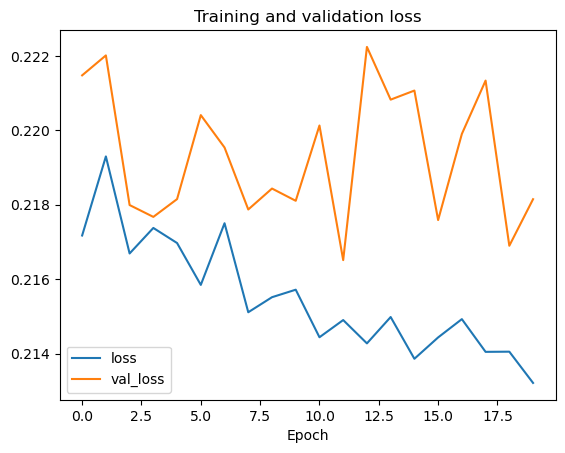

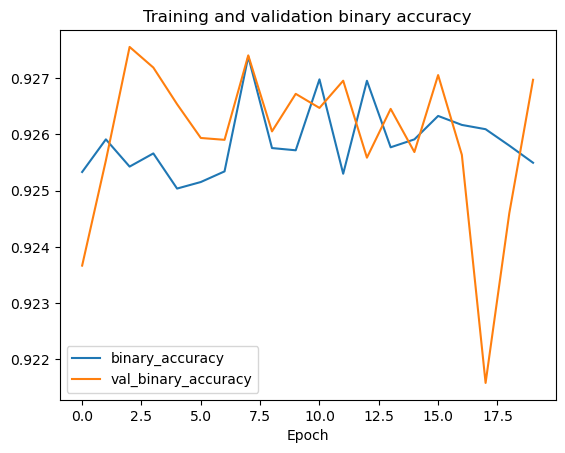

In [ ]:
plot_learning(Resnoaugment_History, title = "Training and validation loss", label = "", metric = "loss", val_metric= "val_loss")
plot_learning(Resnoaugment_History, title = "Training and validation binary accuracy", label = "", metric = "accuracy", val_metric= "val_accuracy")

In [ ]:
classify_noaugment.evaluate(test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 783ms/step - binary_accuracy: 0.9273 - loss: 0.2167 - precision: 0.6631 - recall: 0.1199


[0.21670763194561005,
 0.9272794723510742,
 0.6631016135215759,
 0.11992263048887253]

In [ ]:
predictions = classify_noaugment.predict(test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 724ms/step


In [83]:
predictions.shape

(669, 20)

Get the indicies of the classes with a greater than 0.2

In [ ]:
indices_per_image = np.argmax(predictions, axis=1)


The bottom label is the actual classes and the top label is the predicted classes. As we can see, the predictions are not good.

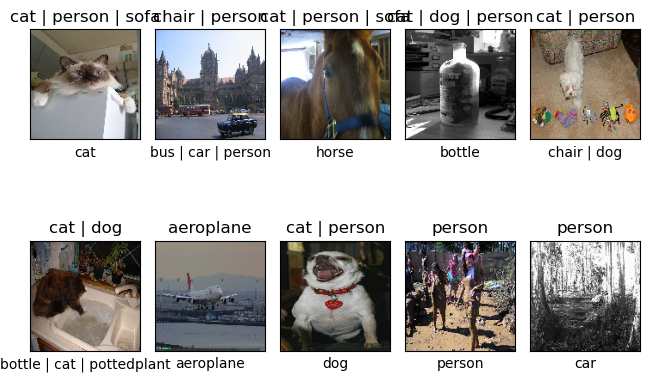

In [ ]:
images, labels = next(test)

plt.figure(figsize = (10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    show_img(images[i]/255.0, list(classes.values())[ (labels[i] == 1).nonzero()[0].item() ], 
            list(classes.values())[ indices_per_image ])

plt.tight_layout()

In [58]:
random_index

6

# Image Augmentation

In this section, you are repeating image classification process but with augmented images for training.
Practice at least two image augmentations and see how much they improve the performance of the model.

I am randomly augmenting half of the images by flipping them left or right, adjusting their contrast by a random value between 0.8 and 1.2, and rotating it between -1 and 1. This will allow me to ensure the model doesn't overfit.

Other than the augmentation, all the model is staying the same.  

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip(mode = "horizontal"),
    layers.RandomRotation(factor = (-.1,.1)),
    layers.RandomZoom(height_factor = (-.2,.2)),
    layers.RandomContrast(factor=0.2)
])

## Method

I am going to standardize the image size to be 128 x 128 x 3. 

The augmenting will be done with random flipping and changing the contrast to ensure I don't overfit on the training data. 

## Experiments

# Image Segmentation

Reviewing the lab practice, create a ResNet-50 based image segmentation model.
You are using the same dataset to replicate the results but with another model.  
Discuss your implementation details.



In [ ]:
seg_ds, info = tfds.load(
    "voc/2012_segmentation",
    split="train",
    with_info=True
)


In [ ]:
model = sm.Unet('resnet50', 
                encoder_weights='imagenet', # Use pre-trained weights
                classes=1,                 # Number of classes
                activation='sigmoid',
                input_shape = (128,128,3=)) 



In [ ]:
## maybe x = image y = mask ????

unetHistory = unet_model.fit(train_batches, epochs = 20, steps_per_epoch=57, validation_data=validation_batches)

In [ ]:
def display(display_list: list): ## bot is bottom
    plt.figure(figsize = (15,15))
    title = ["Input Image", "True Mask", "Predicted Mask"]
    for i in range(len(display_list)):
        plt.subplot(1,len(display_list),i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        plt.axis("off")

    plt.show()

In [ ]:
train_dataset = VOCDetection_dataset["train"].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = VOCDetection_dataset["test"].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset

## Method

## Experiments

# Conclusions

Discuss the challenges or somethat that you learned.
If you have any suggestion about the assignment, you can write about it.

# References

List your references to complete your assignment. Use a proper reference style (APA, MLA, etc.).

## Grading

As of size of images, please do not submit your data. Instead, provide instructions to download them along with the link. Your notebook is supposed to run well after downloading to the working directory.

**Note: this is a WRITING assignment. Proper writing is REQUIRED. Comments are not considered as writing.**


Points | | Description
--|--|:--
5 | Introduction  
10 | Data |
 | 5| description
 | 5| plots for understanding or analysis
30 | Image Classification |
 | 10| Explanation of deep network architecture and implementation
 | 5|  Hyperparameter search
 | 10| Visualization, evaluation of results
 | 5 | Analysis and discussion
15 | Image Augmentation |
 | 5| Explanation of deep network architecture and implementation
 | 5| Visualization, evaluation of results
 | 5 | Analysis and discussion
30 | Image Segmentation |
 | 10| Explanation of deep network architecture and implementation
 | 5|  Hyperparameter search
 | 10| Visualization, evaluation of results
 | 5 | Analysis and discussion
5 | Conclusions
5 | References